# Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('heart_disease_cleaned.csv')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212.0,0,1,168.0,0,1.0,2,2,3,0
1,53,1,0,140.0,203.0,1,0,155.0,1,3.1,0,0,3,0
2,70,1,0,145.0,174.0,0,1,125.0,1,2.6,0,0,3,0
3,61,1,0,148.0,203.0,0,1,161.0,0,0.0,2,1,3,0
4,62,0,0,138.0,294.0,1,1,106.0,0,1.9,1,3,2,0


In [10]:

df.shape

(302, 14)

## 1. Target Variable Distribution


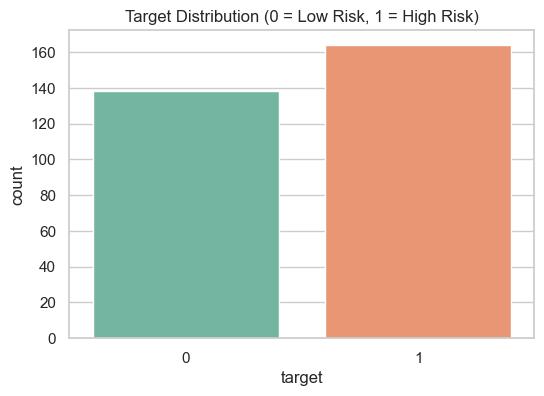

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Target Distribution (0 = Low Risk, 1 = High Risk)')
plt.show()


**Insights/Conclusions:**
The distribution of the target variable shows the balance of our dataset. A relatively balanced target means our models shouldn't suffer from severe class imbalance bias.


## 2. Age Distribution


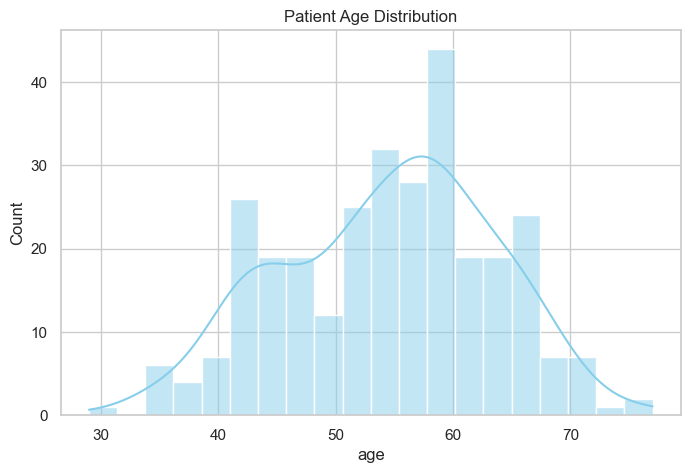

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Patient Age Distribution')
plt.show()


**Insights/Conclusions:**
Most patients in this dataset belong to the age group of 50 to 65. This indicates that middle-aged to senior individuals are more commonly screened for heart disease, which generally aligns with common risk profiles.


## 3. Gender vs Target


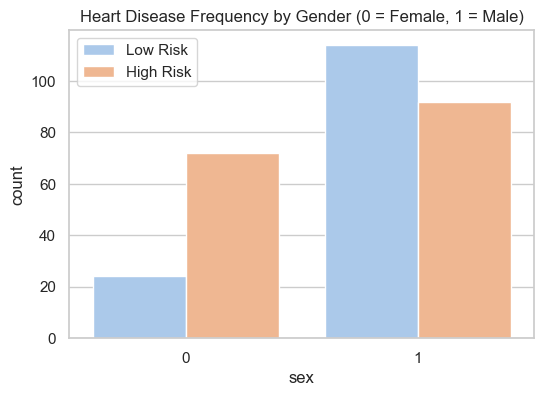

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='target', palette='pastel')
plt.title('Heart Disease Frequency by Gender (0 = Female, 1 = Male)')
plt.legend(['Low Risk', 'High Risk'])
plt.show()


**Insights/Conclusions:**
Males (1) have a higher absolute count of cases compared to females (0), but generally a large proportion of the females in this dataset have a high risk. This feature acts as a significant differentiator.


## 4. Chest Pain Type vs Target


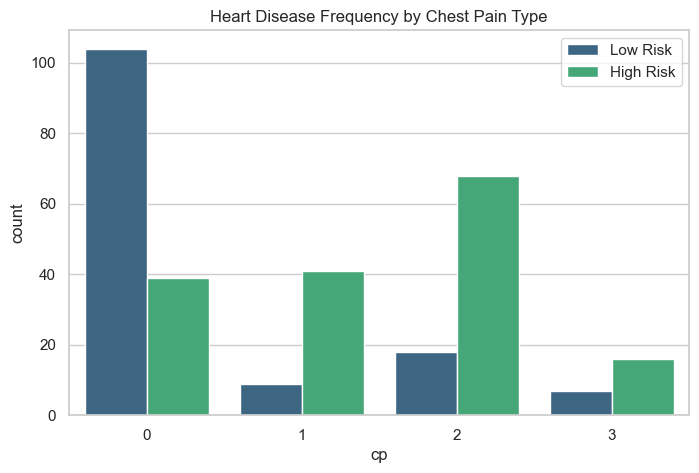

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cp', hue='target', palette='viridis')
plt.title('Heart Disease Frequency by Chest Pain Type')
plt.legend(['Low Risk', 'High Risk'])
plt.show()


**Insights/Conclusions:**
Chest pain types 1, 2, and 3 (atypical angina, non-anginal pain, asymptomatic) show a notably higher likelihood of heart disease compared to type 0 (typical angina). Higher chest pain types clearly reflect strong indicators of disease.


## 5. Cholesterol and Blood Pressure Analysis (Boxplots)


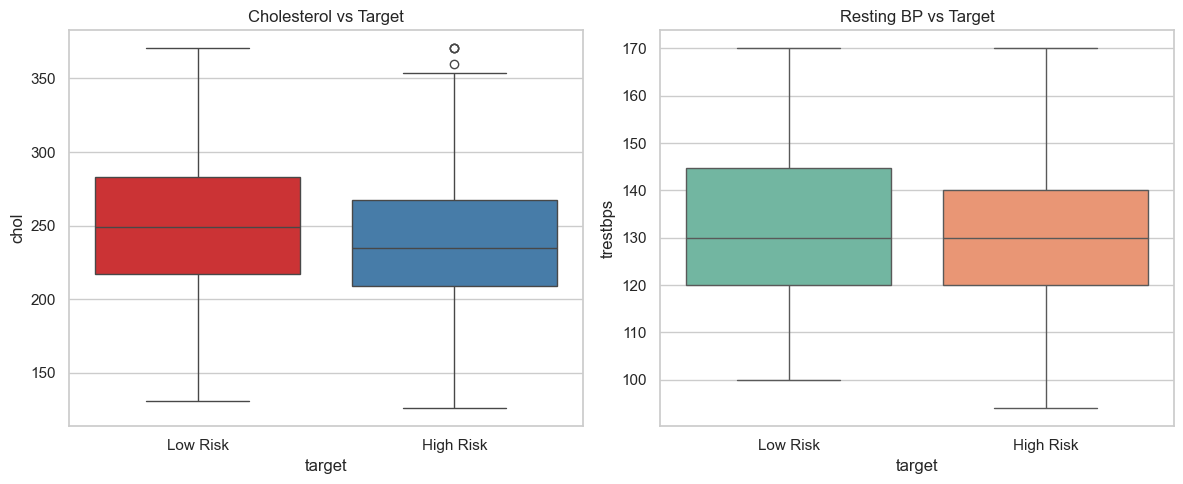

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='target', y='chol', ax=axes[0], palette='Set1')
axes[0].set_title('Cholesterol vs Target')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Low Risk', 'High Risk'])

sns.boxplot(data=df, x='target', y='trestbps', ax=axes[1], palette='Set2')
axes[1].set_title('Resting BP vs Target')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Low Risk', 'High Risk'])

plt.tight_layout()
plt.show()


**Insights/Conclusions:**
Cholesterol and resting blood pressure distributions demonstrate minor shifts between the low and high-risk classes. Those with heart disease generally have slightly more variation in blood pressure. The data looks neat because outliers were handled.


## 6. Correlation Heatmap


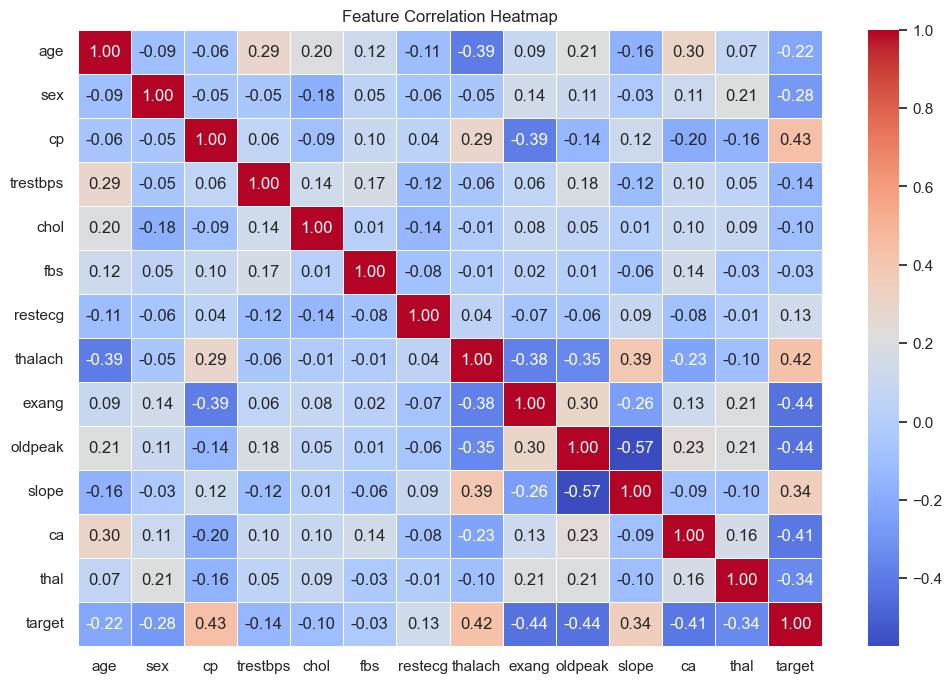

In [8]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


**Insights/Conclusions:**
- `cp` (Chest pain), `thalach` (max heart rate), and `slope` are strongly positively correlated with the presence of disease (`target`).
- `exang` (exercise-induced angina) and `oldpeak` are negatively correlated with the target, meaning lower values of these often relate to higher risk.


## 7. Pairplot of Selected Features


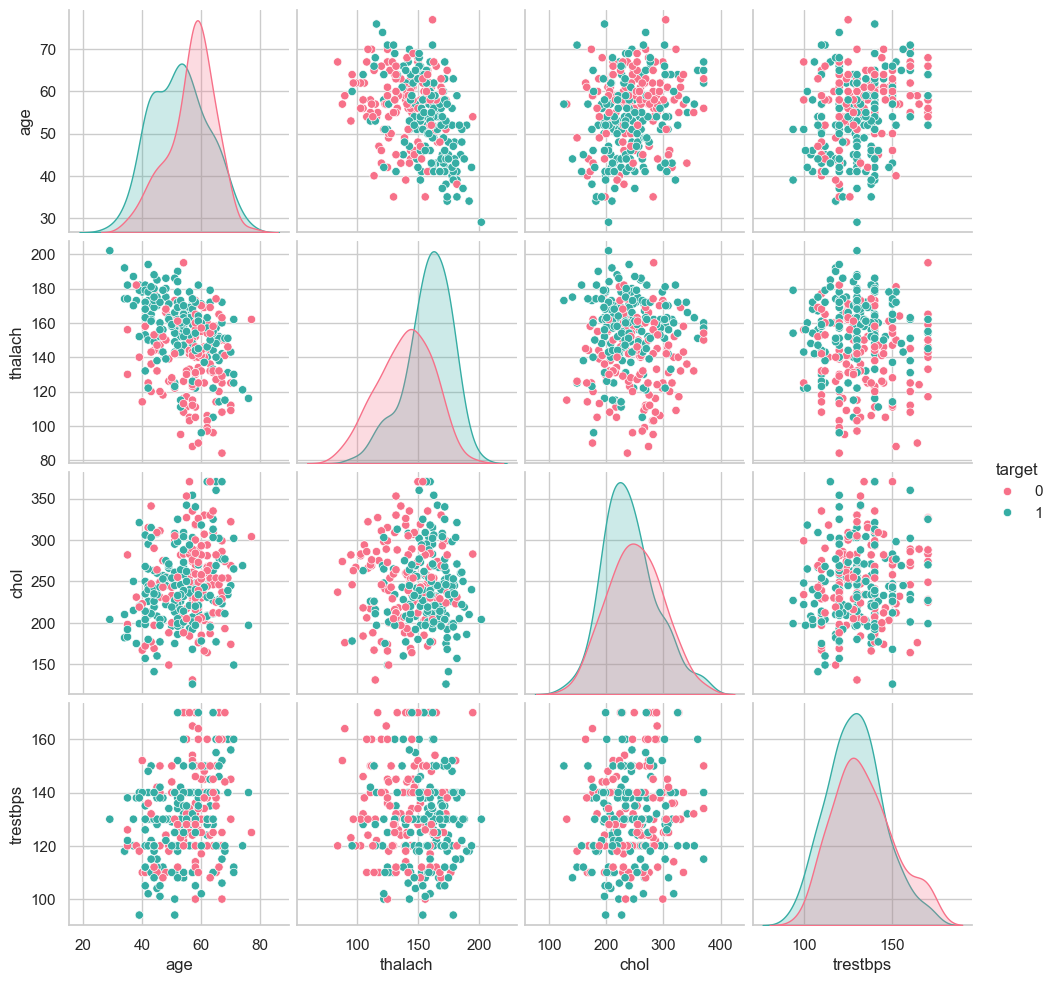

In [9]:
selected_cols = ['age', 'thalach', 'chol', 'trestbps', 'target']
sns.pairplot(df[selected_cols], hue='target', palette='husl')
plt.show()


**Insights/Conclusions:**
The pairplot visualizes pairwise relationships clearly. Patients with lower age might nonetheless show disease if `thalach` is high. Overall, there are no simple straight lines separating the target classes perfectly, underscoring the necessity of using Machine Learning to figure out the complex decision boundaries.
